# NASA EPSCoR Progress: Hybrid Mach-Zehnder Field Propagation
### 20260629 - *Tyndale Stutzman*
---

## Introduction:

This notebook is intended to serve as a hybrid MZ simulation sandbox for simple Jones calculations. The framework allows for rudimentary schematic editing in order to symbolically determine achievable Poincare Sphere (PS) coverage. A brief system and mathematical overview is also provided to verify symbolic/numerical calculations. <!-- working on turning my doc report into a notebook too -->

## Table of Contents

1. [Step 0: Background](#background)
    1. [Optics](#optics)
    3. [Derivation](#math)
3. [Step 1: Setup](#setup)
4. [Step 2: Field Propagation](#prop)
5. [Step 3: Calculation](#calc)
6. [Step 4: Analysis](#analysis)

---


<a id="background"></a>
## Step 0: Background
<a id="optics"></a>
## Optics

The initial optical arrangement for this step of the project aims to use EOMs in order to produce an arbitrary polarization state on the output of a Mach-Zehnder interferometer. A beam with polarization characterized by ```Ein``` enters a polarizing beam splitter where one arm is then modulated by an EOM, imparting a phase shift of ```phi_EOM1```. The two beams then enter into a classical Mach-Zehnder interferometer with one arm containing either a second EOM, or a piezoelectric mirror,```PZT```. For the purposes of this notebook, calculations will be made for the latter case as it will be shown to acheive full coverage of the Poincare Sphere.

<div style="display: flex; gap: 20px; justify-content: center; align-items: flex-start;">

  <figure style="margin: 0; text-align: center;">
    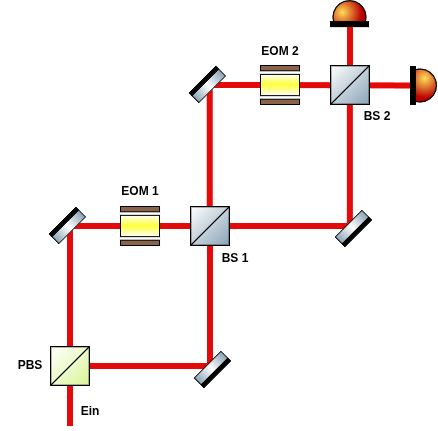
    <figcaption>
      <strong>Figure 1.</strong> Hybrid MZ 2×EOM
    </figcaption>
  </figure>

  <figure style="margin: 0; text-align: center;">
    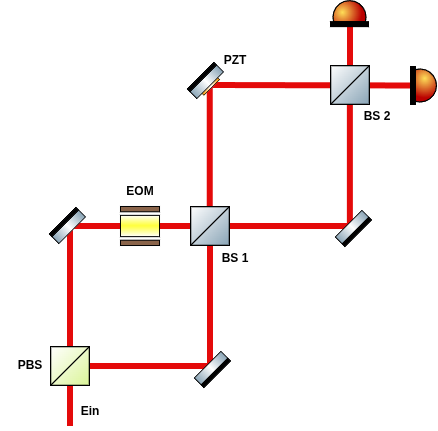
    <figcaption>
      <strong>Figure 2.</strong> Hybrid MZ EOM + PZT
    </figcaption>
  </figure>

</div>

---

<a id="math"></a>
## Derivation

Before running our simulation in python, this mathematical background is provided to more explicitly demonstrate the derivation of the expected results for the case of **Figure 2.**

### Hybrid MZ PZT + EOM: $(\phi_{\mathrm{eom}},\,\phi_{\mathrm{pzt}})\rightarrow(u,v)$

We begin with the Jones vector describing our desired ouput port, armE,

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
a_x\left(e^{i(\phi_e+\delta)}-e^{i(\phi_e+\phi_p+\delta)}\right)/2\\[6pt]
i\,a_y\left(e^{i\phi_p}+1\right)/2
\end{bmatrix},
\end{equation}

where $\phi_e$ is the EOM phase, $\phi_p$ is the PZT phase, and $\delta$ is an additional static phase offset.

For the present derivation we assume

\begin{equation}
\delta=0,
\end{equation}

and equal field amplitudes,

\begin{equation}
a_x=a_y=1.
\end{equation}

The Jones vector becomes

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
\left(e^{i\phi_e}-e^{i(\phi_e+\phi_p)}\right)/2\\[6pt]
i\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}.
\end{equation}

---

### Field Propagation

The interferometer is modeled by propagating the input Jones vector through each optical element in the two arms and recombining the fields at the beam splitters. The transmitted PBS path is defined as armA, while the reflected PBS path is defined as armB. The output port of interest, armE, is obtained after the second beam splitter.

The input field is

\begin{equation}
\mathbf{E}_{in}
=
\begin{bmatrix}
a_x e^{i\delta}\\[6pt]
a_y
\end{bmatrix}
\end{equation}

where $\delta$ is a static phase offset between the polarization components.

The first beam splitter combines the two interferometer arms,

\begin{equation}
\mathbf{E}_{C}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{A}
+
\frac{1}{\sqrt{2}}\mathbf{E}_{B}
\end{equation}

and

\begin{equation}
\mathbf{E}_{D}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{B}
+
\frac{1}{\sqrt{2}}\mathbf{E}_{A}
\end{equation}

After propagation through the PZT phase element in armC and recombination at the second beam splitter, the desired output port is

\begin{equation}
\mathbf{E}_{out}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{C}'
+
\frac{1}{\sqrt{2}}\mathbf{E}_{D}'
\end{equation}

where the primed fields include the accumulated phase shifts from the optical elements.

The EOM introduces a phase shift on the $x$ component,

\begin{equation}
E_x
\rightarrow
E_x e^{i\phi_e}
\end{equation}

while the PZT applies a common phase shift,

\begin{equation}
\mathbf{E}
\rightarrow
e^{i\phi_p}\mathbf{E}
\end{equation}

Combining the two interferometer paths gives the output Jones vector

\begin{equation}
\mathbf{E}_{out}
=
\begin{bmatrix}
a_x\left(e^{i(\phi_e+\delta)}-e^{i(\phi_e+\phi_p+\delta)}\right)/2\\[6pt]
i\,a_y\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}
\end{equation}

where $\phi_e$ is the EOM phase and $\phi_p$ is the PZT phase.

For the polarization-state analysis we assume zero static phase offset,

\begin{equation}
\delta=0
\end{equation}

and equal input field amplitudes,

\begin{equation}
a_x=a_y=1
\end{equation}

giving

\begin{equation}
\boxed{
\mathbf{E}_{out}
=
\begin{bmatrix}
\left(e^{i\phi_e}-e^{i(\phi_e+\phi_p)}\right)/2\\[6pt]
i\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}
}
\end{equation}

### Simplifying the Jones Vector

Factor the exponential in the $x$ component,

\begin{equation}
E_x
=
\frac{e^{i\phi_e}}{2}
\left(1-e^{i\phi_p}\right).
\end{equation}

Using the identity

\begin{equation}
1-e^{i\phi}
=
-2ie^{i\phi/2}\sin\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_x
=
-i
e^{i(\phi_e+\phi_p/2)}
\sin\left(\frac{\phi_p}{2}\right).
\end{equation}

Similarly,

\begin{equation}
E_y
=
\frac{i}{2}
\left(1+e^{i\phi_p}\right),
\end{equation}

and using

\begin{equation}
1+e^{i\phi}
=
2e^{i\phi/2}
\cos\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_y
=
i
e^{i\phi_p/2}
\cos\left(\frac{\phi_p}{2}\right).
\end{equation}

Both components contain the common factor

\begin{equation}
ie^{i\phi_p/2},
\end{equation}

which is a global phase and therefore has no effect on the polarization state. By removing this global phase we arrive at the equivalent Jones vector

\begin{equation}
\boxed{
\mathbf{E}
\sim
\begin{bmatrix}
-\sin\left(\frac{\phi_p}{2}\right)e^{i\phi_e}\\[6pt]
\cos\left(\frac{\phi_p}{2}\right)
\end{bmatrix}
}
\end{equation}

---

### Stokes Parameters

For a normalized Jones vector

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
E_x\\
E_y
\end{bmatrix},
\end{equation}

the normalized Stokes parameters are

\begin{align}
S_1 &= |E_x|^2-|E_y|^2,\\
S_2 &=2\operatorname{Re}(E_xE_y^\ast),\\
S_3 &=2\operatorname{Im}(E_xE_y^\ast).
\end{align}

---

### Calculation of $S_1$

Since

\begin{align}
|E_x|^2
&=
\sin^2\left(\frac{\phi_p}{2}\right),\\
|E_y|^2
&=
\cos^2\left(\frac{\phi_p}{2}\right),
\end{align}

we obtain

\begin{align}
S_1
&=
\sin^2\left(\frac{\phi_p}{2}\right)
-
\cos^2\left(\frac{\phi_p}{2}\right)\\
&=
\boxed{-\cos\phi_p}
\end{align}

---

### Calculation of $S_2$ and $S_3$

First compute

\begin{align}
E_xE_y^\ast
&=
-
\sin\left(\frac{\phi_p}{2}\right)
\cos\left(\frac{\phi_p}{2}\right)
e^{i\phi_e}.
\end{align}

Using

\begin{equation}
2\sin x\cos x=\sin2x,
\end{equation}

gives

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
e^{i\phi_e}.
\end{equation}

Applying Euler's identity,

\begin{equation}
e^{i\phi_e}
=
\cos\phi_e+i\sin\phi_e,
\end{equation}

yields

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
\cos\phi_e
-
i
\frac12
\sin\phi_p
\sin\phi_e.
\end{equation}

Taking the real and imaginary parts,

\begin{align}
S_2
&=
2\operatorname{Re}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\cos\phi_e
}\\[6pt]
S_3
&=
2\operatorname{Im}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\sin\phi_e
}
\end{align}

Therefore the normalized Stokes vector is

\begin{equation}
\boxed{
\mathbf{S}
=
\begin{bmatrix}
-\cos\phi_p\\
-\sin\phi_p\cos\phi_e\\
-\sin\phi_p\sin\phi_e
\end{bmatrix}
}
\end{equation}

---

### Spherical Coordinate Parameterization

Rather than using the Stokes components directly, we can define a spherical coordinate system where the polar axis is the $S_1$ axis. This choice is made in part to simplify the determination of polarization states on the $S_1 = 0$ equator. 

Let

- $v$ denote the polar angle measured from the positive $S_1$ axis,
- $u$ denote the azimuthal angle measured in the $(S_2,S_3)$ plane.

Where the corresponding Cartesian coordinates are

\begin{align}
S_1 &= \cos v,\\
S_2 &= \sin v\cos u,\\
S_3 &= \sin v\sin u.
\end{align}

Comparing these expressions with the Stokes vector we derived above,


\begin{align}
\cos v
&=
-\cos\phi_p,\\
\sin v\cos u
&=
-\sin\phi_p\cos\phi_e,\\
\sin v\sin u
&=
-\sin\phi_p\sin\phi_e,
\end{align}


we find the coordinate transformation

\begin{equation}
\boxed{
v=\pi-\phi_p
}
\end{equation}

and

\begin{equation}
\boxed{
u=\phi_e+\pi
\quad(\mathrm{mod}\;2\pi)
}
\end{equation}

Thus, under the assumptions of equal field amplitudes, $a_x = a_y$, and zero static phase offset $\delta$ in $E_{in}$, the experimental phases directly parameterize the Poincaré sphere:

\begin{equation}
\boxed{
(u,v)
=
(\phi_e+\pi,\;\pi-\phi_p)
}
\end{equation}

In this coordinate system, the PZT phase controls the polar angle on the sphere, while the EOM phase controls the azimuthal rotation about the $S_1$ axis.

---

### Symbolic Extraction of Spherical Coordinates

The spherical coordinate transformation can also be obtained directly from the normalized Stokes vector using the inverse relations

\begin{align}
v &= \cos^{-1}(S_1),\\
u &= \operatorname{atan2}(S_3,S_2).
\end{align}

Applying these expressions directly to the normalized Stokes vector,

\begin{equation}
\mathbf{S}
=
\begin{bmatrix}
-\cos\phi_p\\
-\sin\phi_p\cos\phi_e\\
-\sin\phi_p\sin\phi_e
\end{bmatrix},
\end{equation}

gives

\begin{equation}
v
=
\cos^{-1}(-\cos\phi_p),
\end{equation}

and

\begin{equation}
u
=
\operatorname{atan2}
\left(
-\sin\phi_p\sin\phi_e,
-\sin\phi_p\cos\phi_e
\right).
\end{equation}

Although the expression for $u$ appears to contain both phase variables, the dependence on $\phi_p$ is only an overall scaling factor of the two Cartesian coordinates in the $(S_2,S_3)$ plane. Since the $\operatorname{atan2}$ function determines an angular direction rather than a magnitude, this common factor does not alter the azimuthal coordinate except for possible branch changes associated with the sign of $\sin\phi_p$.

Factoring out the common term gives

\begin{equation}
u
=
\operatorname{atan2}
\left(
-\sin\phi_e,
-\cos\phi_e
\right),
\end{equation}

which corresponds to a rotation of the azimuthal angle by $\pi$,

\begin{equation}
u
=
\phi_e+\pi
\quad(\mathrm{mod}\;2\pi).
\end{equation}

Similarly, the polar coordinate becomes

\begin{equation}
v
=
\cos^{-1}(-\cos\phi_p),
\end{equation}

which, under the standard range $0\leq v\leq\pi$, reduces to

\begin{equation}
v
=
\pi-\phi_p.
\end{equation}

Therefore, the direct symbolic extraction of spherical coordinates from the Stokes parameters is consistent with the analytically derived mapping

\begin{equation}
\boxed{
(u,v)
=
(\phi_e+\pi,\;\pi-\phi_p)
}
\end{equation}

up to the expected $2\pi$ phase periodicity and coordinate branch choices.

---

<a id="setup"></a>
## Step 1: Setup

In [30]:
from sympy import *
from IPython.display import display

init_printing(use_latex="mathjax")

In [31]:
# SYMBOLIC DEFINITIONS

phi, theta, delta = symbols('phi theta delta', real=True)

phi_EOM1 = symbols(r'\phi_{eom}', real=True)
phi_EOM2 = symbols(r'\phi_{2}', real=True)
phi_EOM3 = symbols(r'\phi_{3}', real=True)
phi_PZT1 = symbols(r'\phi_{pzt}', real=True)

Ex, Ey = symbols('E_x E_y', complex=True)

ax, ay = symbols('a_x a_y', real = True)

# Some math definitions:
 
t = 1/sqrt(2)
r = I/sqrt(2)

In [32]:
# INPUT FIELD

# Here Ein is chosen with equal amplitudes where delta = 0 produces a pi/4 linearly polarized beam

Ein = Matrix([
    [ax * exp(I * delta)],
    [ay]
])

display(Ein)

⎡    ⅈ⋅δ⎤
⎢aₓ⋅ℯ   ⎥
⎢       ⎥
⎣  a_y  ⎦

In [33]:
# OPTICAL ELEMENT JONES MATRICES

# Each optical element in the system is defined below.

def Mirror():

    return eye(2)
    

def PBS_T():

    return Matrix([
        [1,0],
        [0,0]
    ])


def PBS_R():

    return Matrix([
        [0,0],
        [0,1]
    ])


def BS(EA, EB):

    t = 1/sqrt(2)
    r = I/sqrt(2)

    EC = simplify(t*EA + r*EB)
    ED = simplify(r*EA + t*EB)

    return EC, ED


def EOM1(phi_EOM1):

    return Matrix([
        [exp(I*phi_EOM1),0],
        [0,1]
    ])

def EOM2(phi_EOM2):

    return Matrix([
        [exp(I*phi_EOM2),0],
        [0,1]
    ])

def EOM3(phi3_EOM3):

    return Matrix([
        [1,0],
        [0,exp(I*phi_EOM3)]
    ])

def PZT(phi_PZT1):

    return Matrix([
        [exp(I*phi_PZT1), 0],
        [0, exp(I*phi_PZT1)]
    ])

In [34]:
# PROPAGATION FUNCTION

def propagate(E, *elements):

    for M in elements:
        E = M * E

    return E

# BEAM SPLITTER COMBINATION FUNCTION

def combine(EA, EB):
    EC = r*EA + t*EB
    ED = r*EB + t*EA
    return EC, ED

<a id="prop"></a>
## Step 2: Field Propagation

This calculation takes the approach of constructing a field for each path between and after beam splitters. For consistency, I have adopted the convention of ```Ex``` being the transmitted path, ```armA```. Notice, each arm takes the incoming Jones Vector and multiplies it by each optical element in that path. 

In [35]:
# PROPAGATE Ein THROUGH INTERFEROMETER

def interferometer(Ein, phi1, phi2):

    armA = propagate(
        Ein,
        PBS_T(),
        Mirror()
    )

    armB = propagate(
        Ein,
        PBS_R(),
        Mirror(),
        PZT(phi_PZT1)
    )

    armC, armD = combine(armA, armB)

    armC = propagate(
        armC,
        Mirror(),
        EOM1(phi1)
    )

    armD = propagate(
        armD,
        Mirror()
    )

    armE, armF = combine(armC, armD)
    
    return {
    "armA": armA,
    "armB": armB,
    "armC": armC,
    "armD": armD,
    "armE": armE,
    "armF": armF,
}

In [36]:
# RUN THE INTERFEROMETER FOR EACH ARM

arms = interferometer(Ein, phi_EOM1, phi_EOM2)

display(simplify(arms["armE"]))
print(simplify(arms["armE"]))

⎡   ⎛ ⅈ⋅δ    ⅈ⋅(\phi_{eom} + δ)⎞⎤
⎢aₓ⋅⎝ℯ    - ℯ                  ⎠⎥
⎢───────────────────────────────⎥
⎢               2               ⎥
⎢                               ⎥
⎢             ⅈ⋅\phi_{pzt}      ⎥
⎣      ⅈ⋅a_y⋅ℯ                  ⎦

Matrix([[a_x*(exp(I*delta) - exp(I*(\phi_{eom} + delta)))/2], [I*a_y*exp(I*\phi_{pzt})]])


<a id="calc"></a>
## Step 3: Calculation

Before numerically manipulating our vectors in python, we can define a chosen coordinate system that allows for a simple mapping from our experimental phase degrees of freedom to angles on the PS. 

### Hybrid MZ PZT + EOM: $(\phi_{\mathrm{eom}},\,\phi_{\mathrm{pzt}})\rightarrow(u,v)$

We begin with the Jones vector describing our desired ouput port, armE,

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
a_x\left(e^{i(\phi_e+\delta)}-e^{i(\phi_e+\phi_p+\delta)}\right)/2\\[6pt]
i\,a_y\left(e^{i\phi_p}+1\right)/2
\end{bmatrix},
\end{equation}

where $\phi_e$ is the EOM phase, $\phi_p$ is the PZT phase, and $\delta$ is an additional static phase offset.

For the present derivation we assume

\begin{equation}
\delta=0,
\end{equation}

and equal field amplitudes,

\begin{equation}
a_x=a_y=1.
\end{equation}

The Jones vector becomes

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
\left(e^{i\phi_e}-e^{i(\phi_e+\phi_p)}\right)/2\\[6pt]
i\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}.
\end{equation}

---

### Step 2: Field Propagation

The interferometer is modeled by propagating the input Jones vector through each optical element in the two arms and recombining the fields at the beam splitters. The transmitted PBS path is defined as armA, while the reflected PBS path is defined as armB. The output port of interest, armE, is obtained after the second beam splitter.

The input field is

\begin{equation}
\mathbf{E}_{in}
=
\begin{bmatrix}
a_x e^{i\delta}\\[6pt]
a_y
\end{bmatrix}
\end{equation}

where $\delta$ is a static phase offset between the polarization components.

The first beam splitter combines the two interferometer arms,

\begin{equation}
\mathbf{E}_{C}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{A}
+
\frac{1}{\sqrt{2}}\mathbf{E}_{B}
\end{equation}

and

\begin{equation}
\mathbf{E}_{D}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{B}
+
\frac{1}{\sqrt{2}}\mathbf{E}_{A}
\end{equation}

After propagation through the PZT phase element in armC and recombination at the second beam splitter, the desired output port is

\begin{equation}
\mathbf{E}_{out}
=
\frac{i}{\sqrt{2}}\mathbf{E}_{C}'
+
\frac{1}{\sqrt{2}}\mathbf{E}_{D}'
\end{equation}

where the primed fields include the accumulated phase shifts from the optical elements.

The EOM introduces a phase shift on the $x$ component,

\begin{equation}
E_x
\rightarrow
E_x e^{i\phi_e}
\end{equation}

while the PZT applies a common phase shift,

\begin{equation}
\mathbf{E}
\rightarrow
e^{i\phi_p}\mathbf{E}
\end{equation}

Combining the two interferometer paths gives the output Jones vector

\begin{equation}
\mathbf{E}_{out}
=
\begin{bmatrix}
a_x\left(e^{i(\phi_e+\delta)}-e^{i(\phi_e+\phi_p+\delta)}\right)/2\\[6pt]
i\,a_y\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}
\end{equation}

where $\phi_e$ is the EOM phase and $\phi_p$ is the PZT phase.

For the polarization-state analysis we assume zero static phase offset,

\begin{equation}
\delta=0
\end{equation}

and equal input field amplitudes,

\begin{equation}
a_x=a_y=1
\end{equation}

giving

\begin{equation}
\boxed{
\mathbf{E}_{out}
=
\begin{bmatrix}
\left(e^{i\phi_e}-e^{i(\phi_e+\phi_p)}\right)/2\\[6pt]
i\left(e^{i\phi_p}+1\right)/2
\end{bmatrix}
}
\end{equation}

## Simplifying the Jones Vector

Factor the exponential in the $x$ component,

\begin{equation}
E_x
=
\frac{e^{i\phi_e}}{2}
\left(1-e^{i\phi_p}\right).
\end{equation}

Using the identity

\begin{equation}
1-e^{i\phi}
=
-2ie^{i\phi/2}\sin\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_x
=
-i
e^{i(\phi_e+\phi_p/2)}
\sin\left(\frac{\phi_p}{2}\right).
\end{equation}

Similarly,

\begin{equation}
E_y
=
\frac{i}{2}
\left(1+e^{i\phi_p}\right),
\end{equation}

and using

\begin{equation}
1+e^{i\phi}
=
2e^{i\phi/2}
\cos\left(\frac{\phi}{2}\right),
\end{equation}

gives

\begin{equation}
E_y
=
i
e^{i\phi_p/2}
\cos\left(\frac{\phi_p}{2}\right).
\end{equation}

Both components contain the common factor

\begin{equation}
ie^{i\phi_p/2},
\end{equation}

which is a global phase and therefore has no effect on the polarization state. By removing this global phase we arrive at the equivalent Jones vector

\begin{equation}
\boxed{
\mathbf{E}
\sim
\begin{bmatrix}
-\sin\left(\frac{\phi_p}{2}\right)e^{i\phi_e}\\[6pt]
\cos\left(\frac{\phi_p}{2}\right)
\end{bmatrix}
}
\end{equation}

---

### Stokes Parameters

For a normalized Jones vector

\begin{equation}
\mathbf{E}
=
\begin{bmatrix}
E_x\\
E_y
\end{bmatrix},
\end{equation}

the normalized Stokes parameters are

\begin{align}
S_1 &= |E_x|^2-|E_y|^2,\\
S_2 &=2\operatorname{Re}(E_xE_y^\ast),\\
S_3 &=2\operatorname{Im}(E_xE_y^\ast).
\end{align}

---

### Calculation of $S_1$

Since

\begin{align}
|E_x|^2
&=
\sin^2\left(\frac{\phi_p}{2}\right),\\
|E_y|^2
&=
\cos^2\left(\frac{\phi_p}{2}\right),
\end{align}

we obtain

\begin{align}
S_1
&=
\sin^2\left(\frac{\phi_p}{2}\right)
-
\cos^2\left(\frac{\phi_p}{2}\right)\\
&=
\boxed{-\cos\phi_p}
\end{align}

---

### Calculation of $S_2$ and $S_3$

First compute

\begin{align}
E_xE_y^\ast
&=
-
\sin\left(\frac{\phi_p}{2}\right)
\cos\left(\frac{\phi_p}{2}\right)
e^{i\phi_e}.
\end{align}

Using

\begin{equation}
2\sin x\cos x=\sin2x,
\end{equation}

gives

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
e^{i\phi_e}.
\end{equation}

Applying Euler's identity,

\begin{equation}
e^{i\phi_e}
=
\cos\phi_e+i\sin\phi_e,
\end{equation}

yields

\begin{equation}
E_xE_y^\ast
=
-\frac12
\sin\phi_p
\cos\phi_e
-
i
\frac12
\sin\phi_p
\sin\phi_e.
\end{equation}

Taking the real and imaginary parts,

\begin{align}
S_2
&=
2\operatorname{Re}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\cos\phi_e
}\\[6pt]
S_3
&=
2\operatorname{Im}(E_xE_y^\ast)
=
\boxed{
-\sin\phi_p\sin\phi_e
}
\end{align}

Therefore the normalized Stokes vector is

\begin{equation}
\boxed{
\mathbf{S}
=
\begin{bmatrix}
-\cos\phi_p\\
-\sin\phi_p\cos\phi_e\\
-\sin\phi_p\sin\phi_e
\end{bmatrix}
}
\end{equation}

---

### Spherical Coordinate Parameterization

Rather than using the Stokes components directly, we can define a spherical coordinate system where the polar axis is the $S_1$ axis. This choice is made in part to simplify the determination of polarization states on the $S_1 = 0$ equator. 

Let

- $v$ denote the polar angle measured from the positive $S_1$ axis,
- $u$ denote the azimuthal angle measured in the $(S_2,S_3)$ plane.

Where the corresponding Cartesian coordinates are

\begin{align}
S_1 &= \cos v,\\
S_2 &= \sin v\cos u,\\
S_3 &= \sin v\sin u.
\end{align}

Comparing these expressions with the Stokes vector we derived above,


\begin{align}
\cos v
&=
-\cos\phi_p,\\
\sin v\cos u
&=
-\sin\phi_p\cos\phi_e,\\
\sin v\sin u
&=
-\sin\phi_p\sin\phi_e,
\end{align}


we find the coordinate transformation

\begin{equation}
\boxed{
v=\pi-\phi_p
}
\end{equation}

and

\begin{equation}
\boxed{
u=\phi_e+\pi
\quad(\mathrm{mod}\;2\pi)
}
\end{equation}

Thus, under the assumptions of equal field amplitudes, $a_x = a_y$, and zero static phase offset $\delta$ in $E_{in}$, the experimental phases directly parameterize the Poincaré sphere:

\begin{equation}
\boxed{
(u,v)
=
(\phi_e+\pi,\;\pi-\phi_p)
}
\end{equation}

In this coordinate system, the PZT phase controls the polar angle on the sphere, while the EOM phase controls the azimuthal rotation about the $S_1$ axis.

---

### Symbolic Extraction of Spherical Coordinates

The spherical coordinate transformation can also be obtained directly from the normalized Stokes vector using the inverse relations

\begin{align}
v &= \cos^{-1}(S_1),\\
u &= \operatorname{atan2}(S_3,S_2).
\end{align}

Applying these expressions directly to the normalized Stokes vector,

\begin{equation}
\mathbf{S}
=
\begin{bmatrix}
-\cos\phi_p\\
-\sin\phi_p\cos\phi_e\\
-\sin\phi_p\sin\phi_e
\end{bmatrix},
\end{equation}

gives

\begin{equation}
v
=
\cos^{-1}(-\cos\phi_p),
\end{equation}

and

\begin{equation}
u
=
\operatorname{atan2}
\left(
-\sin\phi_p\sin\phi_e,
-\sin\phi_p\cos\phi_e
\right).
\end{equation}

Although the expression for $u$ appears to contain both phase variables, the dependence on $\phi_p$ is only an overall scaling factor of the two Cartesian coordinates in the $(S_2,S_3)$ plane. Since the $\operatorname{atan2}$ function determines an angular direction rather than a magnitude, this common factor does not alter the azimuthal coordinate except for possible branch changes associated with the sign of $\sin\phi_p$.

Factoring out the common term gives

\begin{equation}
u
=
\operatorname{atan2}
\left(
-\sin\phi_e,
-\cos\phi_e
\right),
\end{equation}

which corresponds to a rotation of the azimuthal angle by $\pi$,

\begin{equation}
u
=
\phi_e+\pi
\quad(\mathrm{mod}\;2\pi).
\end{equation}

Similarly, the polar coordinate becomes

\begin{equation}
v
=
\cos^{-1}(-\cos\phi_p),
\end{equation}

which, under the standard range $0\leq v\leq\pi$, reduces to

\begin{equation}
v
=
\pi-\phi_p.
\end{equation}

Therefore, the direct symbolic extraction of spherical coordinates from the Stokes parameters is consistent with the analytically derived mapping

\begin{equation}
\boxed{
(u,v)
=
(\phi_e+\pi,\;\pi-\phi_p)
}
\end{equation}

up to the expected $2\pi$ phase periodicity and coordinate branch choices.

In [37]:
# CALCULATION PREREQUISITES

def components(field):

    Ex = field[0]
    Ey = field[1]

    return Ex, Ey


def intensity(field):

    Ex, Ey = components(field)

    return simplify(
        conjugate(Ex)*Ex +
        conjugate(Ey)*Ey
    )

In [38]:
field = arms["armE"]

Ex, Ey = components(field)

Itot = intensity(field)

display(simplify(Itot))

    2  ⅈ⋅\phi_{eom}     2     2  -ⅈ⋅\phi_{eom}       
  aₓ ⋅ℯ               aₓ    aₓ ⋅ℯ                   2
- ───────────────── + ─── - ────────────────── + a_y 
          4            2            4                

In [39]:
# DEFINE STOKES PARAMETERS

def stokes(field):

    Ex, Ey = components(field)

    S0 = simplify(conjugate(Ex)*Ex + conjugate(Ey)*Ey)

    S1 = simplify(conjugate(Ex)*Ex - conjugate(Ey)*Ey)

    S2 = simplify(2*re(Ex*conjugate(Ey)))

    S3 = simplify(2*im(Ex*conjugate(Ey)))

    return Matrix([
        [S0],
        [S1],
        [S2],
        [S3]
    ])

display(simplify(stokes(field)))

⎡         2  ⅈ⋅\phi_{eom}     2     2  -ⅈ⋅\phi_{eom}             ⎤
⎢       aₓ ⋅ℯ               aₓ    aₓ ⋅ℯ                   2      ⎥
⎢     - ───────────────── + ─── - ────────────────── + a_y       ⎥
⎢               4            2            4                      ⎥
⎢                                                                ⎥
⎢         2  ⅈ⋅\phi_{eom}     2     2  -ⅈ⋅\phi_{eom}             ⎥
⎢       aₓ ⋅ℯ               aₓ    aₓ ⋅ℯ                   2      ⎥
⎢     - ───────────────── + ─── - ────────────────── - a_y       ⎥
⎢               4            2            4                      ⎥
⎢                                                                ⎥
⎢-aₓ⋅a_y⋅(sin(\phi_{pzt} - δ) + sin(\phi_{eom} - \phi_{pzt} + δ))⎥
⎢                                                                ⎥
⎣aₓ⋅a_y⋅(-cos(\phi_{pzt} - δ) + cos(\phi_{eom} - \phi_{pzt} + δ))⎦

In [40]:
# EVALUATE STOKES VECTOR

field = arms["armE"]

S = stokes(field)

# Choose experimental parameters

S_eval = simplify(
    S.subs({
        ax: 1/sqrt(2), # Normalized amplitude
        ay: 1/sqrt(2),
        delta: 0,
    })
)

display(S_eval)

print(S_eval)

⎡              3   cos(\phi_{eom})               ⎤
⎢              ─ - ───────────────               ⎥
⎢              4          4                      ⎥
⎢                                                ⎥
⎢               cos(\phi_{eom})   1              ⎥
⎢             - ─────────────── - ─              ⎥
⎢                      4          4              ⎥
⎢                                                ⎥
⎢  sin(\phi_{pzt})   sin(\phi_{eom} - \phi_{pzt})⎥
⎢- ─────────────── - ────────────────────────────⎥
⎢         2                       2              ⎥
⎢                                                ⎥
⎢  cos(\phi_{pzt})   cos(\phi_{eom} - \phi_{pzt})⎥
⎢- ─────────────── + ────────────────────────────⎥
⎣         2                       2              ⎦

Matrix([[3/4 - cos(\phi_{eom})/4], [-cos(\phi_{eom})/4 - 1/4], [-sin(\phi_{pzt})/2 - sin(\phi_{eom} - \phi_{pzt})/2], [-cos(\phi_{pzt})/2 + cos(\phi_{eom} - \phi_{pzt})/2]])


In [41]:
# Confirm S1 = 0 Condition (typically pi or pi/2 depending on architecture)

S_pi = simplify(
    S_eval.subs(phi_PZT1, pi / 2)
)

display(S_pi)

⎡ 3   cos(\phi_{eom}) ⎤
⎢ ─ - ─────────────── ⎥
⎢ 4          4        ⎥
⎢                     ⎥
⎢  cos(\phi_{eom})   1⎥
⎢- ─────────────── - ─⎥
⎢         4          4⎥
⎢                     ⎥
⎢ cos(\phi_{eom})   1 ⎥
⎢ ─────────────── - ─ ⎥
⎢        2          2 ⎥
⎢                     ⎥
⎢   sin(\phi_{eom})   ⎥
⎢   ───────────────   ⎥
⎣          2          ⎦

In [42]:
S_zero = simplify(
    S_eval.subs(phi_PZT1, 0)
)

display(S_zero)

⎡ 3   cos(\phi_{eom}) ⎤
⎢ ─ - ─────────────── ⎥
⎢ 4          4        ⎥
⎢                     ⎥
⎢  cos(\phi_{eom})   1⎥
⎢- ─────────────── - ─⎥
⎢         4          4⎥
⎢                     ⎥
⎢  -sin(\phi_{eom})   ⎥
⎢  ─────────────────  ⎥
⎢          2          ⎥
⎢                     ⎥
⎢ cos(\phi_{eom})   1 ⎥
⎢ ─────────────── - ─ ⎥
⎣        2          2 ⎦

### Parameterization

In [43]:
# GENERALIZED POINCARE SPHERE COORDINATE EXTRACTION

from sympy import atan2, acos, simplify, trigsimp


def poincare_coordinates(S):
    """
    Convert symbolic Stokes vector into spherical coordinates.

    Uses S1 as the polar axis:
    
        S1 = cos(v)
        S2 = sin(v) cos(u)
        S3 = sin(v) sin(u)

    Returns:
        normalized Stokes vector
        u (azimuth)
        v (polar angle)
    """

    # Extract components
    S0 = simplify(S[0])
    S1 = simplify(S[1])
    S2 = simplify(S[2])
    S3 = simplify(S[3])

    # Normalize
    S1n = simplify(S1/S0)
    S2n = simplify(S2/S0)
    S3n = simplify(S3/S0)

    S_norm = Matrix([
        [S1n],
        [S2n],
        [S3n]
    ])

    # Spherical coordinates
    #
    # S1 = cos(v)
    #
    v = simplify(acos(S1n))

    #
    # S2 = sin(v)cos(u)
    # S3 = sin(v)sin(u)
    #
    u = simplify(atan2(S3n, S2n))

    return S_norm, simplify(u), simplify(v)



# APPLY TO YOUR FIELD

field = arms["armE"]

S = stokes(field)


# Experimental substitutions

S_eval = simplify(
    S.subs({
        ax: 1/sqrt(2),
        ay: 1/sqrt(2),
        delta: 0,
    })
)


print("Normalized Stokes:")
S_norm, u_expr, v_expr = poincare_coordinates(S_eval)

display(S_norm)

print("u:")
display(trigsimp(u_expr))

print("v:")
display(trigsimp(v_expr))

print(S_norm)
print("u =", trigsimp(u_expr))
print("v = ", trigsimp(v_expr))

Normalized Stokes:


⎡               cos(\phi_{eom}) + 1                ⎤
⎢               ───────────────────                ⎥
⎢               cos(\phi_{eom}) - 3                ⎥
⎢                                                  ⎥
⎢2⋅(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))⎥
⎢──────────────────────────────────────────────────⎥
⎢               cos(\phi_{eom}) - 3                ⎥
⎢                                                  ⎥
⎢2⋅(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))⎥
⎢──────────────────────────────────────────────────⎥
⎣               cos(\phi_{eom}) - 3                ⎦

u:


     ⎛2⋅(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))  2⋅(sin(\phi_{pzt}) + ↪
atan2⎜──────────────────────────────────────────────────, ──────────────────── ↪
     ⎝               cos(\phi_{eom}) - 3                                 cos(\ ↪

↪  sin(\phi_{eom} - \phi_{pzt}))⎞
↪ ──────────────────────────────⎟
↪ phi_{eom}) - 3                ⎠

v:


    ⎛cos(\phi_{eom}) + 1⎞
acos⎜───────────────────⎟
    ⎝cos(\phi_{eom}) - 3⎠

Matrix([[(cos(\phi_{eom}) + 1)/(cos(\phi_{eom}) - 3)], [2*(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3)], [2*(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3)]])
u = atan2(2*(cos(\phi_{pzt}) - cos(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3), 2*(sin(\phi_{pzt}) + sin(\phi_{eom} - \phi_{pzt}))/(cos(\phi_{eom}) - 3))
v =  acos((cos(\phi_{eom}) + 1)/(cos(\phi_{eom}) - 3))


### Numerical Evaluation

In [44]:
# NUMERICAL FUNCTIONS

from sympy import lambdify
import numpy as np
import matplotlib.pyplot as plt

S_func = lambdify(
    (phi_EOM1, phi_PZT1),
    S_eval,
    modules="numpy"
)

In [45]:
# EVALUATE STOKES NUMERICALLY

def evaluate_stokes(phi1, phi2):

    phi1 = np.asarray(phi1)
    phi2 = np.asarray(phi2)

    phi1, phi2 = np.broadcast_arrays(phi1, phi2)

    S = S_func(phi1, phi2)

    S = np.asarray(S)

    # FORCE consistent shape: (4, N)
    if S.ndim == 2:
        return S
    elif S.ndim == 3:
        return np.squeeze(S)
    else:
        raise ValueError(f"Unexpected shape: {S.shape}")

In [46]:
def normalize_stokes(S):

    S = np.asarray(S)

    S0 = S[0]
    S1 = S[1]
    S2 = S[2]
    S3 = S[3]

    denom = S0

    return np.array([
        S1 / denom,
        S2 / denom,
        S3 / denom
    ])

## Plotting

### 2D S1 = 0

<IPython.core.display.Math object>

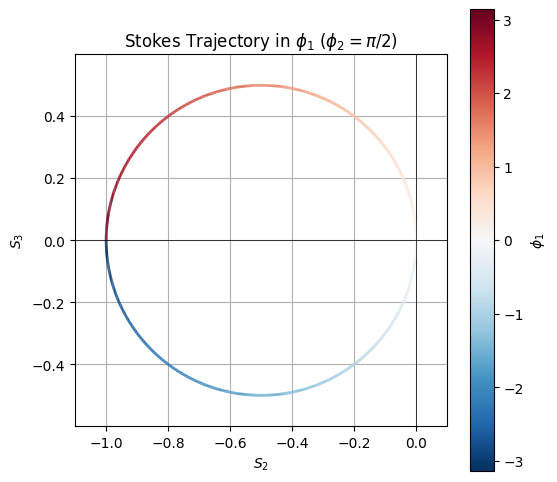

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, Math


phi2_fixed = np.pi / 2

display(Math(r"\phi_1 \mapsto (S_2(\phi_1,\phi_2=\pi/2),\; S_3(\phi_1,\phi_2=\pi/2))"))

phi1_vals = np.linspace(-np.pi, np.pi, 1000)

S2_vals = []
S3_vals = []

for phi1 in phi1_vals:

    # use fixed φ2 = π/2
    S = S_func(phi1, phi2_fixed)
    S = np.squeeze(S)

    S2_vals.append(S[2])
    S3_vals.append(S[3])

S2_vals = np.array(S2_vals)
S3_vals = np.array(S3_vals)


points = np.array([S2_vals, S3_vals]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# color by phi1
norm = plt.Normalize(phi1_vals.min(), phi1_vals.max())
lc = LineCollection(segments, cmap='RdBu_r', norm=norm)
lc.set_array(phi1_vals)
lc.set_linewidth(2)


fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)

x_margin = 0.1 * (S2_vals.max() - S2_vals.min())
y_margin = 0.1 * (S3_vals.max() - S3_vals.min())

ax.set_xlim(S2_vals.min() - x_margin, S2_vals.max() + x_margin)
ax.set_ylim(S3_vals.min() - y_margin, S3_vals.max() + y_margin)

ax.set_xlabel(r"$S_2$")
ax.set_ylabel(r"$S_3$")
ax.set_title(r"Stokes Trajectory in $\phi_1$ ($\phi_2 = \pi/2$)")

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

ax.set_aspect('equal')
ax.grid(True)

cbar = fig.colorbar(lc, ax=ax)
cbar.set_label(r"$\phi_1$")

plt.show()

### 3D

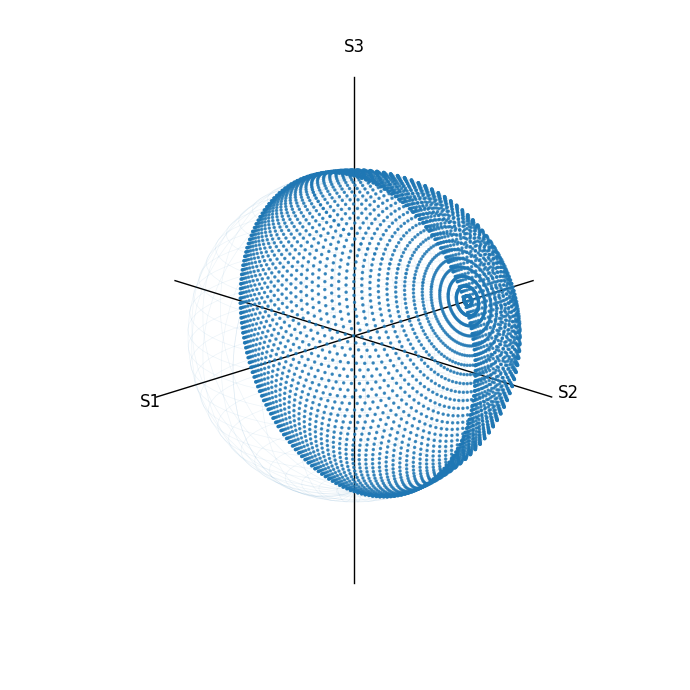

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


S1_grid, S2_grid, S3_grid = [], [], []

phi1_vals = np.linspace(-np.pi, np.pi, 100)
phi2_vals = np.linspace(-np.pi, np.pi, 100)

for p1 in phi1_vals:
    for p2 in phi2_vals:

        S = np.squeeze(S_func(p1, p2))
        S0, S1, S2, S3 = S

        if np.abs(S0) < 1e-12:
            continue

        vec = np.array([S1, S2, S3]) / S0
        vec = np.real(vec)

        S1_grid.append(vec[0])
        S2_grid.append(vec[1])
        S3_grid.append(vec[2])

Sx = np.array(S1_grid)
Sy = np.array(S2_grid)
Sz = np.array(S3_grid)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# REMOVE ALL BOX / PANES
ax.set_axis_off()


ax.scatter(Sx, Sy, Sz, s=2, alpha=0.5)


u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)

xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

ax.plot_wireframe(xs, ys, zs, alpha=0.08, linewidth=0.5)

axis_len = 1.6

# S1 axis
ax.plot([-axis_len, axis_len], [0, 0], [0, 0], color='black', linewidth=1)
ax.text(axis_len * 1.08, 0, 0, "S1", fontsize=12, ha='left', va='center')

# S2 axis
ax.plot([0, 0], [-axis_len, axis_len], [0, 0], color='black', linewidth=1)
ax.text(0, axis_len * 1.08, 0, "S2", fontsize=12, ha='center', va='bottom')

# S3 axis
ax.plot([0, 0], [0, 0], [-axis_len, axis_len], color='black', linewidth=1)
ax.text(0, 0, axis_len * 1.08, "S3", fontsize=12, ha='center', va='bottom')


ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)
ax.set_box_aspect([1, 1, 1])

# no labels, no ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.view_init(elev=18, azim=45)

plt.tight_layout()
plt.show()